In [1]:
# ============================================================
# 🐍 Python Learning Assistant using Vector Databases
# Comparative Analysis of Qdrant and pgvector
# ============================================================

# Objective:
# This project compares two vector databases, Qdrant and pgvector,
# by implementing the same Python Learning Assistant use case using
# semantic search over educational Python articles.

# Embedding Model:
# sentence-transformers/all-MiniLM-L6-v2

# Vector Databases Compared:
# 1. Qdrant
# 2. pgvector (PostgreSQL Extension)

# Platform:
# Google Colab (CPU Runtime) / Local Jupyter

# Workflow:
# 1. Load and chunk Python tutorial articles.
# 2. Generate embeddings using Sentence Transformers.
# 3. Store embeddings in Qdrant.
# 4. Store the same embeddings in pgvector.
# 5. Answer learning questions using semantic similarity.
# 6. Compare search results and performance.


In [2]:
# ============================================================
# CELL 2 : Install Required Python Libraries
# ============================================================

!pip -q install qdrant-client sentence-transformers pandas tabulate matplotlib psycopg2-binary


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.2/396.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 74.4 MB/s eta 0:00:00


In [3]:
# ============================================================
# CELL 3 : Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import re
import json
from pathlib import Path

from sentence_transformers import SentenceTransformer

from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance,
    VectorParams,
    PointStruct
)

print("✅ Libraries imported successfully.")


✅ Libraries imported successfully.


In [4]:
# ============================================================
# CELL 4 : Load and Chunk Python Articles
# ============================================================
ARTICLES_PATH = "python_articles.md"

with open(ARTICLES_PATH, "r", encoding="utf-8") as f:
    raw_md = f.read()

# Split on top-level article headings: "# Article N: ..."
article_blocks = re.split(r"(?=^# Article \d+:)", raw_md, flags=re.MULTILINE)
article_blocks = [b.strip() for b in article_blocks if b.strip() and b.strip().startswith("# Article")]

records = []
for block in article_blocks:
    # Title line
    first_line = block.split("\n", 1)[0]
    title_match = re.match(r"# Article (\d+):\s*(.+)", first_line)
    if not title_match:
        continue
    article_id = int(title_match.group(1))
    title = title_match.group(2).strip()

    # Extract major sections
    sections = re.split(r"(?=^## )", block, flags=re.MULTILINE)
    for sec in sections:
        sec = sec.strip()
        if not sec or sec.startswith("# Article"):
            continue
        sec_lines = sec.split("\n")
        sec_heading = sec_lines[0].lstrip("# ").strip()
        sec_body = "\n".join(sec_lines[1:]).strip()
        if len(sec_body) < 40:
            continue
        # Further split long sections into ~400-char chunks for better retrieval
        paragraphs = [p.strip() for p in re.split(r"\n\s*\n", sec_body) if p.strip()]
        chunk_text = ""
        chunk_idx = 0
        for para in paragraphs:
            if len(chunk_text) + len(para) > 450 and chunk_text:
                records.append({
                    "id": f"A{article_id}_S{sec_heading[:20]}_{chunk_idx}",
                    "article_id": article_id,
                    "title": title,
                    "section": sec_heading,
                    "content": chunk_text.strip(),
                    "text_for_embedding": f"{title} | {sec_heading}: {chunk_text.strip()}"
                })
                chunk_idx += 1
                chunk_text = para
            else:
                chunk_text = (chunk_text + "\n\n" + para).strip() if chunk_text else para
        if chunk_text.strip():
            records.append({
                "id": f"A{article_id}_S{sec_heading[:20]}_{chunk_idx}",
                "article_id": article_id,
                "title": title,
                "section": sec_heading,
                "content": chunk_text.strip(),
                "text_for_embedding": f"{title} | {sec_heading}: {chunk_text.strip()}"
            })

df = pd.DataFrame(records)
print(f"✅ Loaded {len(df)} text chunks from {df['article_id'].nunique()} articles.\n")
display(df[["article_id", "title", "section"]].drop_duplicates().reset_index(drop=True))
print("\nSample chunk:")
print(df.iloc[0]["text_for_embedding"][:300], "...")


✅ Loaded 70 text chunks from 5 articles.



,article_id,title,section
0,1,Python Variables and Data Types,Introduction
1,1,Python Variables and Data Types,Main Concepts
2,1,Python Variables and Data Types,Examples
3,1,Python Variables and Data Types,Common Operations
4,1,Python Variables and Data Types,Comparison With Related Python Concepts
5,1,Python Variables and Data Types,Common Mistakes
6,1,Python Variables and Data Types,Practical Use Cases
7,1,Python Variables and Data Types,Conclusion
8,2,Python Strings,Introduction
9,2,Python Strings,Main Concepts



Sample chunk:
Python Variables and Data Types | Introduction: When you start learning Python, one of the very first things you need to understand is how the language stores information. This is done through **variables**. A variable is simply a name that points to a value stored in the computer's memory. Along wi ...


In [5]:
# ============================================================
# CELL 5 : Generate Embeddings
# ============================================================

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print("Generating embeddings for all chunks...")
embeddings = embedding_model.encode(
    df["text_for_embedding"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

df["embedding"] = list(embeddings)
VECTOR_DIM = embeddings.shape[1]

print(f"✅ Generated {len(embeddings)} embeddings of dimension {VECTOR_DIM}.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings for all chunks...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

✅ Generated 70 embeddings of dimension 384.


In [6]:
# ============================================================
# CELL 6 : Initialize Qdrant Vector Database
# ============================================================

# In-memory Qdrant client (no external server needed for demo)
qdrant_client = QdrantClient(":memory:")

collection_name = "python_articles"

print("✅ Qdrant client initialized (in-memory mode).")


✅ Qdrant client initialized (in-memory mode).


In [7]:
# ============================================================
# CELL 7 : Create Qdrant Collection
# ============================================================

# Recreate collection if it already exists
qdrant_client.recreate_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(
        size=VECTOR_DIM,
        distance=Distance.COSINE
    )
)

print(f"✅ Collection '{collection_name}' created with Cosine distance.")


✅ Collection 'python_articles' created with Cosine distance.


/tmp/ipykernel_2747/1619375439.py:6: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  qdrant_client.recreate_collection(


In [8]:
# ============================================================
# CELL 8 : Upload Article Chunks into Qdrant
# ============================================================

points = []
for idx, row in df.iterrows():
    point = PointStruct(
        id=idx,
        vector=row["embedding"].tolist(),
        payload={
            "article_id": int(row["article_id"]),
            "title": row["title"],
            "section": row["section"],
            "content": row["content"]
        }
    )
    points.append(point)

qdrant_client.upsert(
    collection_name=collection_name,
    points=points
)

info = qdrant_client.get_collection(collection_name)
print(f"✅ Uploaded {len(points)} chunks into Qdrant.")
print(f"📊 Total vectors stored: {info.points_count}")


✅ Uploaded 70 chunks into Qdrant.
📊 Total vectors stored: 70


In [9]:
# ============================================================
# CELL 9 : Verify Collection Information
# ============================================================

info = qdrant_client.get_collection(collection_name)

print("Collection Name :", collection_name)
print("Vectors Stored  :", info.points_count)
print("Distance Metric :", info.config.params.vectors.distance)


Collection Name : python_articles
Vectors Stored  : 70
Distance Metric : Cosine


In [10]:
# ============================================================
# CELL 10 : Semantic Search using Qdrant
# ============================================================

def search_python_qdrant(query: str, top_k: int = 5):
    """Search Python article chunks using semantic similarity in Qdrant."""
    query_vector = embedding_model.encode(query).tolist()

    start = time.perf_counter()
    results = qdrant_client.query_points(
        collection_name=collection_name,
        query=query_vector,
        limit=top_k
    )
    elapsed_ms = (time.perf_counter() - start) * 1000

    rows = []
    for p in results.points:
        rows.append({
            "Article": p.payload["title"],
            "Section": p.payload["section"],
            "Similarity": round(p.score, 4),
            "Snippet": p.payload["content"][:180] + "..."
        })
    return pd.DataFrame(rows), elapsed_ms


# Example query
example_q = "What is the difference between lists and tuples?"
res_df, q_time = search_python_qdrant(example_q)

print("Query:", example_q)
print(f"Qdrant Search Time: {q_time:.2f} ms\n")
display(res_df)


Query: What is the difference between lists and tuples?
Qdrant Search Time: 2.08 ms



,Article,Section,Similarity,Snippet
0,Python Lists,Comparison With Related Python Concepts,0.8450,"Because lists are mutable, they are generally ..."
1,Python Tuples,Comparison With Related Python Concepts,0.7867,The most important comparison is between tuple...
2,Python Tuples,Main Concepts,0.7799,"Like lists, tuples are **ordered**, meaning ea..."
3,Python Lists,Conclusion,0.7408,"Lists are ordered, mutable collections that ca..."
4,Python Tuples,Conclusion,0.7292,"Tuples are ordered, immutable sequences that a..."


---
## Part 2 – PostgreSQL + pgvector
The same embeddings and queries will now be evaluated on pgvector for a fair comparison.


In [11]:
# ============================================================
# CELL 11 : Install PostgreSQL + pgvector (Run Once)
# ============================================================

# Install PostgreSQL
!apt-get update -qq
!apt-get install -y postgresql postgresql-common postgresql-contrib postgresql-server-dev-14 build-essential git

import os
if not os.path.exists("pgvector"):
    !git clone https://github.com/pgvector/pgvector.git

%cd pgvector
!make
!make install
%cd ..

!pg_ctlcluster 14 main start
!sudo -u postgres psql -c "ALTER USER postgres PASSWORD 'postgres';"
!sudo -u postgres psql -c "CREATE DATABASE python_db;" || echo "python_db already exists"
!pg_ctlcluster 14 main restart
!sudo -u postgres psql -d python_db -c "CREATE EXTENSION IF NOT EXISTS vector;"

print("✅ PostgreSQL + pgvector setup completed.")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
git is already the newest version (1:2.34.1-1ubuntu1.17).
The following additional packages will be installed:
  binfmt-support clang-14 lib32gcc-s1 lib32stdc++6 libc-dev-bin libc6
  libc6-dev libc6-i386 libclang-common-14-dev libclang-cpp14 libclang1-14
  libcommon-sense-perl libgc1 libjson-perl libjson-xs-perl libllvm14
  libobjc-11-dev libobjc4 libpfm4 libtypes-serialiser-perl libz3-4 libz3-dev
  llvm-14 llvm-14-dev llvm-14-linker-tools llvm-14-runtime llvm-14-tools
  logrotate netbase postgresql-14 postgresql-client-14
  postgresql-client-common python3-pygments python3-yaml ssl-cert sysstat
Suggested packages:
  clang-14-doc glibc-doc llvm-

In [12]:
# ============================================================
# CELL 12 : Connect to PostgreSQL
# ============================================================

import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="python_db",
    user="postgres",
    password="postgres",
    port=5432
)
cursor = conn.cursor()

print("✅ Connected to PostgreSQL successfully.")


✅ Connected to PostgreSQL successfully.


In [13]:
# ============================================================
# CELL 13 : Create Table with VECTOR Column
# ============================================================

cursor.execute("DROP TABLE IF EXISTS python_chunks;")
cursor.execute(f"""
CREATE TABLE python_chunks(
    id INTEGER PRIMARY KEY,
    article_id INTEGER,
    title TEXT,
    section TEXT,
    content TEXT,
    embedding VECTOR({VECTOR_DIM})
);
""")
conn.commit()
print("✅ python_chunks table created.")


✅ python_chunks table created.


In [14]:
# ============================================================
# CELL 14 : Insert Embeddings into pgvector
# ============================================================

conn.rollback()
cursor.execute("TRUNCATE TABLE python_chunks;")

insert_sql = """
INSERT INTO python_chunks (id, article_id, title, section, content, embedding)
VALUES (%s, %s, %s, %s, %s, %s)
"""

for idx, row in df.iterrows():
    emb_str = "[" + ",".join(map(str, row["embedding"].tolist())) + "]"
    cursor.execute(insert_sql, (
        int(idx),
        int(row["article_id"]),
        row["title"],
        row["section"],
        row["content"],
        emb_str
    ))

conn.commit()

cursor.execute("SELECT COUNT(*) FROM python_chunks;")
count = cursor.fetchone()[0]
print(f"✅ Inserted {count} records into pgvector.")


✅ Inserted 70 records into pgvector.


In [15]:
# ============================================================
# CELL 15 : Verify Records in pgvector
# ============================================================

cursor.execute("SELECT COUNT(*) FROM python_chunks;")
print("Records Stored:", cursor.fetchone()[0])


Records Stored: 70


In [16]:
# ============================================================
# CELL 16 : Semantic Search using pgvector
# ============================================================

def search_python_pgvector(query: str, top_k: int = 5):
    """Search Python article chunks using cosine distance in pgvector."""
    query_vector = embedding_model.encode(query).tolist()
    emb_str = "[" + ",".join(map(str, query_vector)) + "]"

    start = time.perf_counter()
    cursor.execute(f"""
        SELECT title, section, content,
               1 - (embedding <=> %s::vector) AS similarity
        FROM python_chunks
        ORDER BY embedding <=> %s::vector
        LIMIT %s;
    """, (emb_str, emb_str, top_k))
    rows = cursor.fetchall()
    elapsed_ms = (time.perf_counter() - start) * 1000

    result = [{
        "Article": r[0],
        "Section": r[1],
        "Similarity": round(float(r[3]), 4),
        "Snippet": r[2][:180] + "..."
    } for r in rows]
    return pd.DataFrame(result), elapsed_ms


example_q = "What is the difference between lists and tuples?"
res_df, pg_time = search_python_pgvector(example_q)

print("Query:", example_q)
print(f"pgvector Search Time: {pg_time:.2f} ms\n")
display(res_df)


Query: What is the difference between lists and tuples?
pgvector Search Time: 10.26 ms



,Article,Section,Similarity,Snippet
0,Python Lists,Comparison With Related Python Concepts,0.8450,"Because lists are mutable, they are generally ..."
1,Python Tuples,Comparison With Related Python Concepts,0.7867,The most important comparison is between tuple...
2,Python Tuples,Main Concepts,0.7799,"Like lists, tuples are **ordered**, meaning ea..."
3,Python Lists,Conclusion,0.7408,"Lists are ordered, mutable collections that ca..."
4,Python Tuples,Conclusion,0.7292,"Tuples are ordered, immutable sequences that a..."


In [17]:
# ============================================================
# CELL 17 : Compare Qdrant and pgvector on All Questions
# ============================================================

# Load questions
QUESTIONS_PATH = "questions.json"
with open(QUESTIONS_PATH, "r", encoding="utf-8") as f:
    questions = json.load(f)

comparison_results = []
all_answers = []

for q in questions:
    qid = q["id"]
    text = q["question"]

    qdrant_df, q_time = search_python_qdrant(text, top_k=3)
    pg_df, pg_time = search_python_pgvector(text, top_k=3)

    comparison_results.append({
        "Question ID": qid,
        "Question": text,
        "Qdrant Top Hit": qdrant_df.iloc[0]["Article"] if len(qdrant_df) else "-",
        "pgvector Top Hit": pg_df.iloc[0]["Article"] if len(pg_df) else "-",
        "Qdrant Time (ms)": round(q_time, 2),
        "pgvector Time (ms)": round(pg_time, 2)
    })

    all_answers.append({
        "qid": qid,
        "question": text,
        "qdrant": qdrant_df,
        "pgvector": pg_df
    })

comparison_df = pd.DataFrame(comparison_results)

print("✅ Comparison completed successfully.\n")
display(comparison_df)


✅ Comparison completed successfully.



,Question ID,Question,Qdrant Top Hit,pgvector Top Hit,Qdrant Time (ms),pgvector Time (ms)
0,1,What are Python variables?,Python Variables and Data Types,Python Variables and Data Types,1.86,1.29
1,2,What is dynamic typing in Python?,Python Variables and Data Types,Python Variables and Data Types,1.59,1.12
2,3,What is the difference between lists and tuple...,Python Lists,Python Lists,1.47,0.99
3,4,Why are tuples immutable?,Python Tuples,Python Tuples,1.46,1.03
4,5,What are Python dictionaries used for?,Python Dictionaries,Python Dictionaries,1.64,1.78
5,6,What is type casting in Python?,Python Variables and Data Types,Python Variables and Data Types,1.43,1.16
6,7,How are Python lists different from sets?,Python Lists,Python Lists,1.62,1.09
7,8,How do you access values in a Python dictionary?,Python Dictionaries,Python Dictionaries,1.74,1.21
8,9,When should you use a tuple instead of a list?,Python Lists,Python Lists,1.69,1.18
9,10,What are the main built-in data types in Python?,Python Variables and Data Types,Python Variables and Data Types,1.54,1.07


In [18]:
# ============================================================
# CELL 18 : Detailed Retrieval Examples
# ============================================================

for item in all_answers[:5]:   # first 5 questions
    print("=" * 70)
    print(f"Q{item['qid']}: {item['question']}")
    print("-" * 70)
    print("Qdrant results:")
    display(item["qdrant"])
    print("pgvector results:")
    display(item["pgvector"])
    print()


Q1: What are Python variables?
----------------------------------------------------------------------
Qdrant results:


,Article,Section,Similarity,Snippet
0,Python Variables and Data Types,Introduction,0.8149,"When you start learning Python, one of the ver..."
1,Python Variables and Data Types,Examples,0.7643,This flexibility is part of what makes Python ...
2,Python Variables and Data Types,Conclusion,0.7566,Variables and data types form the building blo...


pgvector results:


,Article,Section,Similarity,Snippet
0,Python Variables and Data Types,Introduction,0.8149,"When you start learning Python, one of the ver..."
1,Python Variables and Data Types,Examples,0.7643,This flexibility is part of what makes Python ...
2,Python Variables and Data Types,Conclusion,0.7566,Variables and data types form the building blo...



Q2: What is dynamic typing in Python?
----------------------------------------------------------------------
Qdrant results:


...

,Article,Section,Similarity,Snippet
0,Python Tuples,Main Concepts,0.7770,This is an important and often surprising deta...
1,Python Tuples,Introduction,0.6710,Tuples are another fundamental ordered data st...
2,Python Tuples,Main Concepts,0.6497,"Like lists, tuples are **ordered**, meaning ea..."



Q5: What are Python dictionaries used for?
----------------------------------------------------------------------
Qdrant results:


,Article,Section,Similarity,Snippet
0,Python Dictionaries,Practical Use Cases,0.8632,Dictionaries are extremely common in real-worl...
1,Python Dictionaries,Introduction,0.7409,Dictionaries are one of the most powerful and ...
2,Python Dictionaries,Main Concepts,0.7328,"A dictionary is created using curly braces, wi..."


pgvector results:


,Article,Section,Similarity,Snippet
0,Python Dictionaries,Practical Use Cases,0.8632,Dictionaries are extremely common in real-worl...
1,Python Dictionaries,Introduction,0.7409,Dictionaries are one of the most powerful and ...
2,Python Dictionaries,Main Concepts,0.7328,"A dictionary is created using curly braces, wi..."


Average Qdrant Search Time   : 1.60 ms
Average pgvector Search Time : 1.19 ms


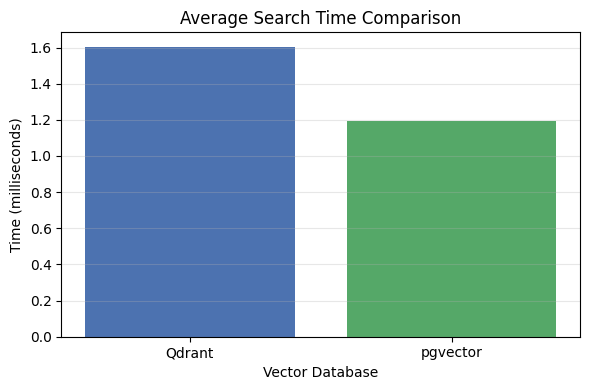

In [19]:
# ============================================================
# CELL 19 : Performance Comparison Chart
# ============================================================

avg_qdrant = comparison_df["Qdrant Time (ms)"].mean()
avg_pgvector = comparison_df["pgvector Time (ms)"].mean()

print(f"Average Qdrant Search Time   : {avg_qdrant:.2f} ms")
print(f"Average pgvector Search Time : {avg_pgvector:.2f} ms")

plt.figure(figsize=(6, 4))
plt.bar(["Qdrant", "pgvector"], [avg_qdrant, avg_pgvector], color=["#4C72B0", "#55A868"])
plt.title("Average Search Time Comparison")
plt.ylabel("Time (milliseconds)")
plt.xlabel("Vector Database")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
# ============================================================
# CELL 20 : Evaluation Summary
# ============================================================

evaluation_df = pd.DataFrame({
    "Evaluation Metric": [
        "Use Case",
        "Embedding Model",
        "Similarity Metric",
        "Metadata Support",
        "Database Type",
        "Average Search Time",
        "Number of Chunks Indexed"
    ],
    "Qdrant": [
        "Python Learning Assistant",
        "all-MiniLM-L6-v2",
        "Cosine Similarity",
        "Payload Metadata Filtering",
        "Dedicated Vector Database",
        f"{avg_qdrant:.2f} ms",
        str(len(df))
    ],
    "pgvector": [
        "Python Learning Assistant",
        "all-MiniLM-L6-v2",
        "Cosine Similarity",
        "SQL WHERE + Vector Search",
        "PostgreSQL Extension",
        f"{avg_pgvector:.2f} ms",
        str(len(df))
    ]
})

print("========== FINAL EVALUATION ==========\n")
display(evaluation_df)

print("\n========== PROJECT CONCLUSION ==========\n")
print("""
1. Both Qdrant and pgvector successfully retrieved relevant Python article
   sections for natural-language learning questions using semantic similarity.

2. Qdrant was simpler to set up for pure vector search (in-memory mode works
   out of the box) and is well-suited for AI-native applications.

3. pgvector integrates semantic search directly inside PostgreSQL, which is
   ideal when the application already relies on a relational database and
   needs SQL joins / filters alongside vector search.

4. Because both systems used the same embeddings, the same chunking strategy,
   and the same set of questions, the comparison is fair and demonstrates how
   different vector databases solve the same retrieval problem.
""")


========== FINAL EVALUATION ==========



,Evaluation Metric,Qdrant,pgvector
0,Use Case,Python Learning Assistant,Python Learning Assistant
1,Embedding Model,all-MiniLM-L6-v2,all-MiniLM-L6-v2
2,Similarity Metric,Cosine Similarity,Cosine Similarity
3,Metadata Support,Payload Metadata Filtering,SQL WHERE + Vector Search
4,Database Type,Dedicated Vector Database,PostgreSQL Extension
5,Average Search Time,1.60 ms,1.19 ms
6,Number of Chunks Indexed,70,70



========== PROJECT CONCLUSION ==========


1. Both Qdrant and pgvector successfully retrieved relevant Python article
   sections for natural-language learning questions using semantic similarity.

2. Qdrant was simpler to set up for pure vector search (in-memory mode works
   out of the box) and is well-suited for AI-native applications.

3. pgvector integrates semantic search directly inside PostgreSQL, which is
   ideal when the application already relies on a relational database and
   needs SQL joins / filters alongside vector search.

4. Because both systems used the same embeddings, the same chunking strategy,
   and the same set of questions, the comparison is fair and demonstrates how
   different vector databases solve the same retrieval problem.

